# Verify Data Quality

This step is used to identify data quality issues and assess how clean the data is before preparing it for modeling.

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from omegaconf import OmegaConf
from olist_ml.config import OlistConfig
from sqlalchemy import create_engine
from sklearn.preprocessing import MinMaxScaler

root_path = project_root=Path.cwd().parent.parent
cfg = OmegaConf.load("../../conf/config.yaml")

raw_data_path = root_path / cfg.paths.raw_data
olist_sqlite_path = raw_data_path / cfg.files.olist_sqlite
db_file = f"sqlite:///{olist_sqlite_path}"
engine = create_engine(db_file)
orders = pd.read_sql("SELECT * FROM orders;", engine)
order_items = pd.read_sql("SELECT * FROM order_items;", engine)
products = pd.read_sql("SELECT * FROM products;", engine)
customers = pd.read_sql("SELECT * FROM customers;", engine)
product_category_name_translation = pd.read_sql("SELECT * FROM product_category_name_translation;", engine)
order_payments = pd.read_sql("SELECT * FROM order_payments;", engine)
order_reviews = pd.read_sql("SELECT * FROM order_reviews;", engine)
sellers = pd.read_sql("SELECT * FROM sellers;", engine)
geolocation = pd.read_sql("SELECT * FROM geolocation;", engine)
leads_closed = pd.read_sql("SELECT * FROM leads_closed;", engine)
leads_qualified = pd.read_sql("SELECT * FROM leads_qualified;", engine)

## Missing Values

In [2]:
order_items_merged = pd.merge(
    pd.merge(
        order_items,
        pd.merge(
            products,
            product_category_name_translation,
            how="left",
            on="product_category_name"
        ),
        how="left",
        on="product_id"
    ),
    orders,
    how="left",
    on="order_id"
)

categories_to_keep = (
    order_items_merged
    .groupby("product_category_name")
    .size()
    .loc[lambda x: x >= 3000]
    .index
)
order_items_filtered = order_items_merged[
    order_items_merged["product_category_name"].isin(categories_to_keep)
]
print(f"Total order items: {len(order_items_filtered)}")
print(order_items_filtered.isna().sum())
print(order_items_filtered.isna().sum().sum())

Total order items: 86066
order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
product_category_name               0
product_name_lenght                 0
product_description_lenght          0
product_photos_qty                  0
product_weight_g                    1
product_length_cm                   1
product_height_cm                   1
product_width_cm                    1
product_category_name_english       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  12
order_delivered_carrier_date      849
order_delivered_customer_date    1851
order_estimated_delivery_date       0
dtype: int64
2716


There are missing values in the following variables: `product_weight_g` (1), `product_length_cm` (1), `product_height_cm` (1), `product_width_cm` (1), `order_approved_at` (12), `order_delivered_carrier_date` (849), and `order_delivered_customer_date` (1851).

Out of a total of 86066 order items, there are 2716 missing values, mainly in `order_delivered_carrier_date` and `order_delivered_customer_date`.

## Duplicates and Uniqueness

In [3]:
print(
    f"Order items original length: {len(order_items)} "
    f"Order items merged: {len(order_items_merged)}"
)

print(
    f"Duplicate order item identifiers: "
    f"{order_items_filtered[['order_id', 'order_item_id']].duplicated().sum()}"
)

print(
    f"Fully duplicated order item records: "
    f"{order_items_merged.duplicated().sum()}"
)

Order items original length: 112650 Order items merged: 112650
Duplicate order item identifiers: 0
Fully duplicated order item records: 0


No duplicate order items were found, and no additional order items were introduced during the merging process.

## Ranges and Invalid values

Total order items: 86066
Outliers count (price > 800 BRL or freight_value > 80 BRL): 1522


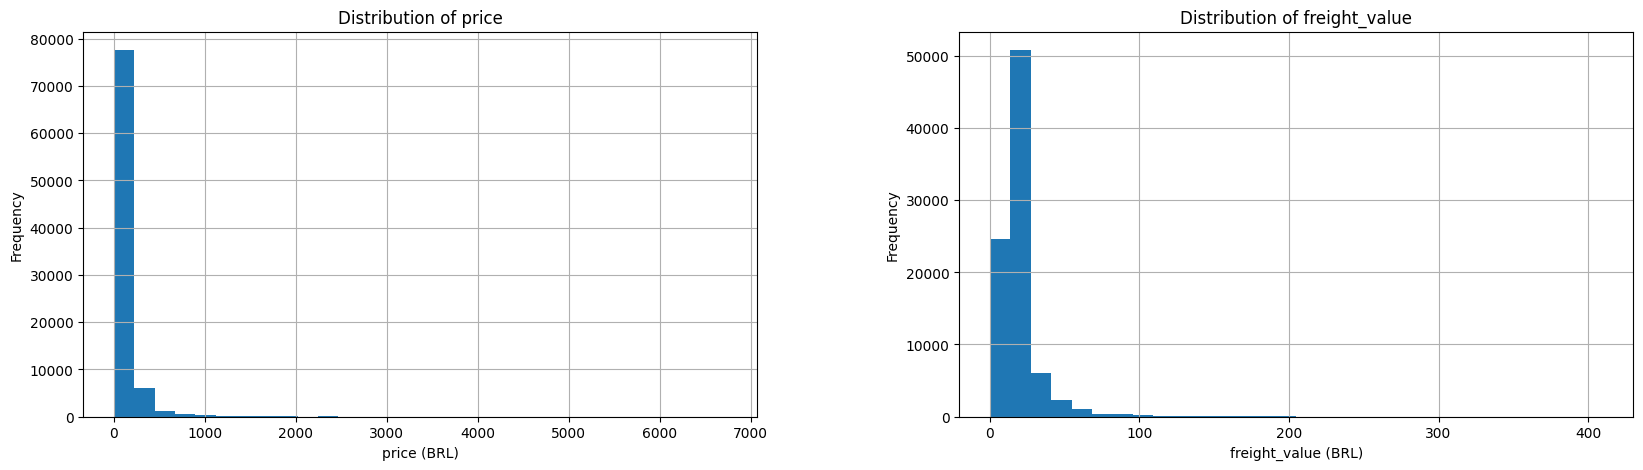

In [4]:
axes = order_items_filtered[["price", "freight_value"]].hist(
    figsize=(20, 5),
    bins=30
)

for ax, col in zip(axes.flatten(), ["price", "freight_value"]):
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(f"{col} (BRL)")
    ax.set_ylabel("Frequency")

plt.savefig("../../docs/images/price_freight_distribution.png", dpi=300)
plt.plot()

outliers_count = order_items_filtered[
    (order_items_filtered["price"] > 800) |
    (order_items_filtered["freight_value"] > 80)
].shape[0]
print(f"Total order items: {len(order_items_filtered)}")
print(
    f"Outliers count (price > 800 BRL or freight_value > 80 BRL): {outliers_count}"
)

The number of outliers with price greater than 800 BRL or freight value greater than 80 BRL is 1522.

Total order items (price <= 800 BRL and freight_value <= 80 BRL): 84544


[]

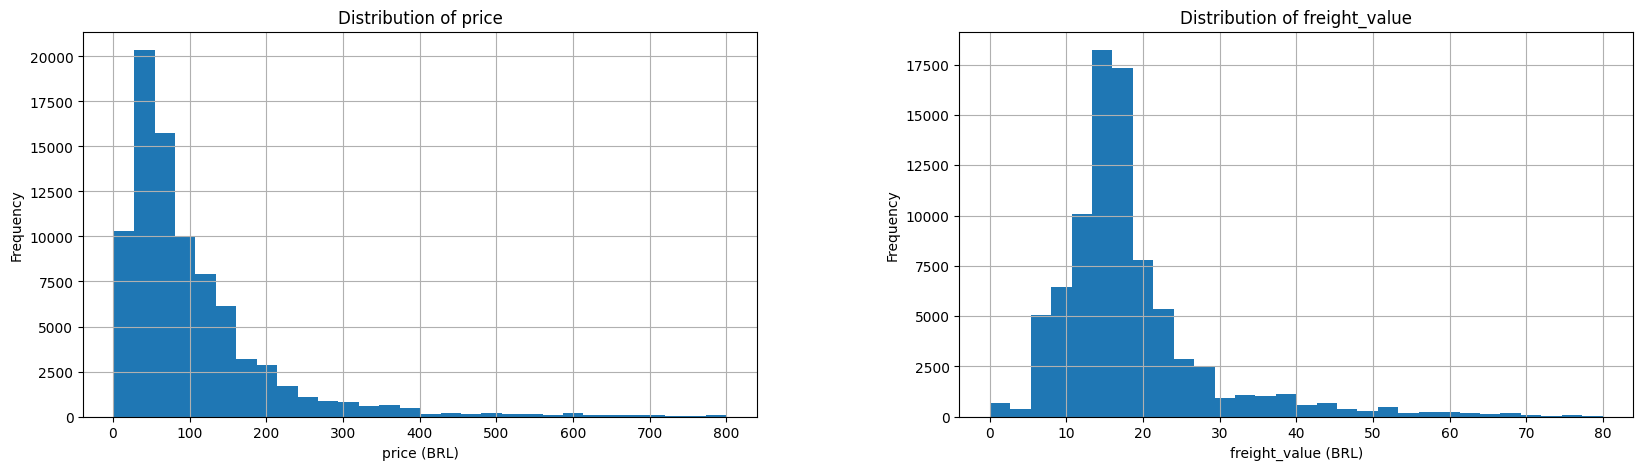

In [5]:
order_items_lower_price_800_freight_value_80 = order_items_filtered[
    (order_items_filtered["price"] <= 800) &
    (order_items_filtered["freight_value"] <= 80)
]
print(f"Total order items (price <= 800 BRL and freight_value <= 80 BRL): {len(order_items_lower_price_800_freight_value_80)}")

axes = order_items_lower_price_800_freight_value_80[["price", "freight_value"]].hist(
    figsize=(20, 5),
    bins=30
)

for ax, col in zip(axes.flatten(), ["price", "freight_value"]):
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(f"{col} (BRL)")
    ax.set_ylabel("Frequency")

plt.savefig("../../docs/images/price_freight_distribution_after.png", dpi=300)
plt.plot()

- The distribution of price shows that most order items are concentrated between 0 and 400 BRL.
- The distribution of freight value shows that most order items are concentrated between 0 and 50 BRL.